In [71]:
#Librerias
import pandas as pd
from pathlib import Path
import glob
import os

import seaborn as sns

import numpy as np
from scipy.stats import chi2_contingency
from scipy.stats import zscore
from scipy import stats

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import matplotlib.dates as mdates
import matplotlib.ticker as ticker

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller




In [2]:
# CARGAR DATOS
ruta_datos = Path(r"C:\Users\Dell\Desktop\MARCO UDLA\PROYECTO MBD\BDD\Datos")

grupo_2005_2011 = {
    2005: "volumen_ene_dic_2005.xlsb",
    2006: "volumen_ene_dic_2006.xlsb",
    2007: "volumen_ene_dic_2007.xlsb",
    2008: "volumen_ene_dic_2008.xlsb",
    2009: "volumen_ene_dic_2009.xlsb",
    2010: "volumen_ene_dic_2010.xlsb",
    2011: "volumen_ene_dic_2011.xlsb",
}

dfs_2005_2011 = []

for anio, archivo in grupo_2005_2011.items():
    print(f"\nCargando {archivo}")

    df = pd.read_excel(
        ruta_datos / archivo,
        engine="pyxlsb",
        header=5
    )

    print("Filas leídas:", df.shape[0])

    df["ANIO"] = anio
    dfs_2005_2011.append(df)

print("\nCantidad de DataFrames cargados:", len(dfs_2005_2011))


df_2005_2011 = pd.concat(dfs_2005_2011, ignore_index=True)


df_2005_2011.shape
df_2005_2011.columns
df_2005_2011.head()




Cargando volumen_ene_dic_2005.xlsb
Filas leídas: 194434

Cargando volumen_ene_dic_2006.xlsb
Filas leídas: 190882

Cargando volumen_ene_dic_2007.xlsb
Filas leídas: 200777

Cargando volumen_ene_dic_2008.xlsb
Filas leídas: 256516

Cargando volumen_ene_dic_2009.xlsb
Filas leídas: 227768

Cargando volumen_ene_dic_2010.xlsb
Filas leídas: 217477

Cargando volumen_ene_dic_2011.xlsb
Filas leídas: 233148

Cantidad de DataFrames cargados: 7


,FECHA,ANIO,SUBSISTEMA,ENTIDAD,TIPO DE CREDITO,REGION,PROVINCIA,CANTON,SECTOR,SUBSECTOR,ACTIVIDAD,MONTO OTORGADO,NUMERO DE OPERACIONES
0,31/1/2005,2005,BANCOS PRIVADOS EXTRANJEROS,BP CITIBANK,COMERCIAL,SIERRA,DE COTOPAXI,LATACUNGA,COMERCIO AL POR MAYOR Y AL POR MENOR; REPARACI...,COMERCIO AL POR MAYOR Y AL POR MENOR; REPARACI...,"COMERCIO DE PARTES, PIEZAS Y ACCESORIOS DE VEH...",100000.00,1
1,31/1/2005,2005,BANCOS PRIVADOS EXTRANJEROS,BP CITIBANK,COMERCIAL,COSTA,DE MANABI,MANTA,"AGRICULTURA, GANADERIA, SILVICULTURA, PESCA Y ...",AGRICULTURA,CULTIVO DE ALGODON EN RAMA,1682994.50,2
2,31/1/2005,2005,BANCOS PRIVADOS EXTRANJEROS,BP CITIBANK,COMERCIAL,SIERRA,DE PICHINCHA,QUITO,"ACTIVIDADES PROFESIONALES, TECNICAS Y ADMINIST...","ACTIVIDADES PROFESIONALES, TECNICAS Y ADMINIST...",ACTIVIDADES DE ADMINISTRACION DE EMPRESAS Y CO...,8194.36,1
3,31/1/2005,2005,BANCOS PRIVADOS EXTRANJEROS,BP CITIBANK,COMERCIAL,SIERRA,DE PICHINCHA,QUITO,"ACTIVIDADES PROFESIONALES, TECNICAS Y ADMINIST...","ACTIVIDADES PROFESIONALES, TECNICAS Y ADMINIST...",ACTIVIDADES DE ALQUILER Y ARRENDAMIENTO (EXCEP...,95000.00,1
4,31/1/2005,2005,BANCOS PRIVADOS EXTRANJEROS,BP CITIBANK,COMERCIAL,SIERRA,DE PICHINCHA,QUITO,ADMINISTRACION PUBLICA Y DEFENSA; PLANES DE SE...,ADMINISTACION PUBLICA Y DEFENSA; PLANES DE SEG...,"ADM PUBLICA, DEFENSA; PLANES SEG SOCIAL OBLIGA...",7945.12,1


In [3]:
grupo_2012_2014 = {
    2012: "volumen_ene_dic_2012.xlsb",
    2013: "volumen_ene_dic_2013.xlsb",
    2014: "volumen_ene_dic_2014.xlsb",
}

dfs_2012_2014 = []

dfs_2012_2014 = []

for anio, archivo in grupo_2012_2014.items():
    print(f"\nCargando {archivo}")

    df = pd.read_excel(
        ruta_datos / archivo,
        engine="pyxlsb",
        header=5
    )

    print("Filas leídas:", df.shape[0])

    df["ANIO"] = anio
    dfs_2012_2014.append(df)

print("\nCantidad de DataFrames cargados:", len(dfs_2012_2014))


df_2012_2014 = pd.concat(dfs_2012_2014, ignore_index=True)

df_2012_2014.shape
df_2012_2014.columns
df_2012_2014.head()


Cargando volumen_ene_dic_2012.xlsb
Filas leídas: 258392

Cargando volumen_ene_dic_2013.xlsb
Filas leídas: 196721

Cargando volumen_ene_dic_2014.xlsb
Filas leídas: 190940

Cantidad de DataFrames cargados: 3


,FECHA,ANIO,SUBSISTEMA,ENTIDAD,TIPO DE CREDITO,TIPO DE OPERACIÓN,PROVINCIA,CANTON,SECTOR,SUBSECTOR,ACTIVIDAD,MONTO OTORGADO,NUMERO DE OPERACIONES
0,31/1/2012,2012,BANCOS PRIVADOS EXTRANJEROS,BP CITIBANK,COMERCIAL,CREDITO,DE PICHINCHA,QUITO,ACTIVIDADES FINANCIERAS Y DE SEGUROS,ACTIVIDADES FINANCIERAS Y DE SEGUROS,SEGUROS (DE VIDA Y GENERALES) Y REASEGUROS,17623.49,1
1,31/1/2012,2012,BANCOS PRIVADOS EXTRANJEROS,BP CITIBANK,COMERCIAL,CONTINGENTE,DE PICHINCHA,QUITO,ACTIVIDADES INMOBILIARIAS,"ACTIVIDADES INMOBILIARIAS,",ACTIVIDADES INMOBILIARIAS,18855.75,1
2,31/1/2012,2012,BANCOS PRIVADOS EXTRANJEROS,BP CITIBANK,COMERCIAL,CREDITO,DE PICHINCHA,QUITO,"ACTIVIDADES PROFESIONALES, TECNICAS Y ADMINIST...","ACTIVIDADES PROFESIONALES, TECNICAS Y ADMINIST...",ACTIVIDADES DE ADMINISTRACION DE EMPRESAS Y CO...,925000.00,3
3,31/1/2012,2012,BANCOS PRIVADOS EXTRANJEROS,BP CITIBANK,COMERCIAL,CONTINGENTE,DE ESMERALDAS,ESMERALDAS,ADMINISTRACION PUBLICA Y DEFENSA; PLANES DE SE...,ADMINISTACION PUBLICA Y DEFENSA; PLANES DE SEG...,"ADM PUBLICA, DEFENSA; PLANES SEG SOCIAL OBLIGA...",2509.07,1
4,31/1/2012,2012,BANCOS PRIVADOS EXTRANJEROS,BP CITIBANK,COMERCIAL,CONTINGENTE,DE PICHINCHA,QUITO,ADMINISTRACION PUBLICA Y DEFENSA; PLANES DE SE...,ADMINISTACION PUBLICA Y DEFENSA; PLANES DE SEG...,"ADM PUBLICA, DEFENSA; PLANES SEG SOCIAL OBLIGA...",1846714.72,18


In [4]:
grupo_2015_2025 = {
    2015: "volumen_ene_dic_2015.xlsb",
    2016: "volumen_ene_dic_2016.xlsb",
    2017: "volumen_ene_dic_2017.xlsb",
    2018: "volumen_ene_dic_2018.xlsb",
    2019: "volumen_ene_dic_2019.xlsb",
    2020: "volumen_ene_dic_2020.xlsb",
    2021: "volumen_ene_dic_2021.xlsb",
    2022: "volumen_ene_dic_2022.xlsb",
    2023: "volumen_ene_dic_2023.xlsb",
    2024: "volumen_ene_dic_2024.xlsb",
    2025: "volumen_ene_dic_2025.xlsb",}

dfs_2015_2025 = []

for anio, archivo in grupo_2015_2025.items():
    print(f"\nCargando {archivo}")

    df = pd.read_excel(
        ruta_datos / archivo,
        engine="pyxlsb",
        header=5
    )

    print("Filas leídas:", df.shape[0])

    df["ANIO"] = anio
    dfs_2015_2025.append(df)

print("\nCantidad de DataFrames cargados:", len(dfs_2015_2025))


df_2015_2025 = pd.concat(dfs_2015_2025, ignore_index=True)

df_2015_2025.shape
df_2015_2025.columns
df_2015_2025.head()


Cargando volumen_ene_dic_2015.xlsb
Filas leídas: 208288

Cargando volumen_ene_dic_2016.xlsb
Filas leídas: 229307

Cargando volumen_ene_dic_2017.xlsb
Filas leídas: 237701

Cargando volumen_ene_dic_2018.xlsb
Filas leídas: 246000

Cargando volumen_ene_dic_2019.xlsb
Filas leídas: 228992

Cargando volumen_ene_dic_2020.xlsb
Filas leídas: 217688

Cargando volumen_ene_dic_2021.xlsb
Filas leídas: 233459

Cargando volumen_ene_dic_2022.xlsb
Filas leídas: 228503

Cargando volumen_ene_dic_2023.xlsb
Filas leídas: 291764

Cargando volumen_ene_dic_2024.xlsb
Filas leídas: 230551

Cargando volumen_ene_dic_2025.xlsb
Filas leídas: 228108

Cantidad de DataFrames cargados: 11


,FECHA,ANIO,SUBSISTEMA,ENTIDAD,TIPO DE CREDITO,TIPO DE OPERACION,ESTADO DE LA OPERACION,PROVINCIA,CANTON,SECTOR,SUBSECTOR,ACTIVIDAD,NUMERO DE OPERACIONES,MONTO OTORGADO
0,31/1/2015,2015,BANCOS PRIVADOS,BP AMAZONAS,COMERCIAL PRIORITARIO CORPORATIVO,CREDITO,ORIGINAL,DE PICHINCHA,QUITO,"ACTIVIDADES PROFESIONALES, TÉCNICAS Y ADMINIST...","ACTIVIDADES PROFESIONALES, TÉCNICAS Y ADMINIST...","OTRAS ACTIVIDADES PROFESIONALES, CIENTÍFICAS Y...",1,1012.33
1,31/1/2015,2015,BANCOS PRIVADOS,BP AMAZONAS,COMERCIAL PRIORITARIO CORPORATIVO,CREDITO,ORIGINAL,DE PICHINCHA,QUITO,COMERCIO AL POR MAYOR Y AL POR MENOR; REPARACI...,COMERCIO AL POR MAYOR Y AL POR MENOR; REPARACI...,COMERCIO AL POR MENOR DE OTROS PRODUCTOS NCP,1,1745.28
2,31/1/2015,2015,BANCOS PRIVADOS,BP AMAZONAS,COMERCIAL PRIORITARIO CORPORATIVO,CREDITO,ORIGINAL,DE PICHINCHA,QUITO,COMERCIO AL POR MAYOR Y AL POR MENOR; REPARACI...,COMERCIO AL POR MAYOR Y AL POR MENOR; REPARACI...,"COMERCIO DE PARTES, PIEZAS Y ACCESORIOS DE VEH...",2,67414.68
3,31/1/2015,2015,BANCOS PRIVADOS,BP AMAZONAS,COMERCIAL PRIORITARIO CORPORATIVO,CREDITO,ORIGINAL,DE PICHINCHA,QUITO,CONSTRUCCIÓN,CONSTRUCCIÓN,CONSTRUCCIÓN DE EDIFICIOS\n\n\n,1,10000.00
4,31/1/2015,2015,BANCOS PRIVADOS,BP AMAZONAS,COMERCIAL PRIORITARIO CORPORATIVO,CREDITO,ORIGINAL,DE PICHINCHA,QUITO,INDUSTRIAS MANUFACTURERAS,FABRICACIÓN DE PRODUCTOS QUÍMICOS; DEL CAUCHO ...,FABRICACIÓN DE PRODUCTOS DE CAUCHO\n\n\n\n\n,1,13.19


In [5]:
#ELIMINAR CAMPOS NO NECESARIOS
df_2005_2011 = df_2005_2011.drop(
    columns=["REGION"],
    errors="ignore"
)

df_2012_2014 = df_2012_2014.drop(
    columns=["TIPO DE OPERACIÓN"],
    errors="ignore"
)

df_2015_2025 = df_2015_2025.drop(
    columns=["TIPO DE OPERACION", "ESTADO DE LA OPERACION"],
    errors="ignore"
)


In [6]:
#ORDENAR CAMPOS EN df_2015_2025

orden_columnas = [
    "FECHA",
    "ANIO",
    "SUBSISTEMA",
    "ENTIDAD",
    "TIPO DE CREDITO",
    "PROVINCIA",
    "CANTON",
    "SECTOR",
    "SUBSECTOR",
    "ACTIVIDAD",
    "NUMERO DE OPERACIONES",
    "MONTO OTORGADO"
]

df_2015_2025 = df_2015_2025.reindex(columns=orden_columnas)


In [15]:
df_total = pd.concat(
    [df_2005_2011, df_2012_2014, df_2015_2025],
    ignore_index=True
)

df_total.head()
df_total.tail()

,FECHA,ANIO,SUBSISTEMA,ENTIDAD,TIPO DE CREDITO,PROVINCIA,CANTON,SECTOR,SUBSECTOR,ACTIVIDAD,MONTO OTORGADO,NUMERO DE OPERACIONES
4747411,31/12/2025,2025,INSTITUCIONES FINANCIERAS PUBLICAS,BANECUADOR B. P.,PRODUCTIVO PYMES,GUAYAS,GUAYAQUIL,TRANSPORTE Y ALMACENAMIENTO,TRANSPORTE DE PASAJEROS MARÍTIMO Y DE CABOTAJE,"TRANSPORTE MARÍTIMO Y DE CABOTAJE, REGULAR Y N...",125395.18,1
4747412,31/12/2025,2025,INSTITUCIONES FINANCIERAS PUBLICAS,BANECUADOR B. P.,PRODUCTIVO PYMES,LOS RIOS,QUEVEDO,COMERCIO AL POR MAYOR Y AL POR MENOR; REPARACI...,"VENTA AL POR MAYOR DE TEXTILES, PRENDAS DE VES...",VENTA AL POR MAYOR DE CALZADO,13119.85,1
4747413,31/12/2025,2025,INSTITUCIONES FINANCIERAS PUBLICAS,BANECUADOR B. P.,PRODUCTIVO PYMES,PICHINCHA,SAN MIGUEL DE LOS BANCOS,CONSTRUCCIÓN,PREPARACIÓN DEL TERRENO,LIMPIEZA DE TERRENOS DE CONSTRUCCIÓN,12380.52,1
4747414,31/12/2025,2025,INSTITUCIONES FINANCIERAS PUBLICAS,BANECUADOR B. P.,PRODUCTIVO PYMES,GUAYAS,GUAYAQUIL,COMERCIO AL POR MAYOR Y AL POR MENOR; REPARACI...,"VENTA AL POR MAYOR DE MAQUINARIA, EQUIPO Y MAT...",VENTA AL POR MAYOR DE MAQUINARIA Y EQUIPO AGRO...,297499.97,1
4747415,31/12/2025,2025,INSTITUCIONES FINANCIERAS PUBLICAS,BANECUADOR B. P.,PRODUCTIVO PYMES,MANABI,MANTA,OTRAS ACTIVIDADES DE SERVICIOS,ACTIVIDADES DE PELUQUERÍA Y OTROS TRATAMIENTOS...,"ACTIVIDADES DE LAVADO, CORTE, RECORTE, PEINADO...",107368.44,1


In [16]:
#Filtros de Entidades Privadas grandes
entidades = [
    "BP PICHINCHA",
    "BP GUAYAQUIL",
    "BP PACIFICO",
    "BP PRODUBANCO"
]

df_Previo = df_total[
      df_total["ENTIDAD"].isin(entidades)
]

In [9]:
df_Previo["ANIO"] = df_Previo["ANIO"].astype(str)

C:\Users\Dell\AppData\Local\Temp\ipykernel_4392\2326269029.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_Previo["ANIO"] = df_Previo["ANIO"].astype(str)


In [17]:
#tipo de datos y no nulos

resumen_info = pd.DataFrame({
    'Variable': df_Previo.columns,
    'Tipo_dato': df_Previo.dtypes.values,
    'No_null': df_Previo.count().values,
    'Nulos': df_Previo.shape[0] - df_Previo.count().values
})

resumen_info

,Variable,Tipo_dato,No_null,Nulos
0,FECHA,object,1532125,0
1,ANIO,int64,1532125,0
2,SUBSISTEMA,object,1532125,0
3,ENTIDAD,object,1532125,0
4,TIPO DE CREDITO,object,1532125,0
5,PROVINCIA,object,1532125,0
6,CANTON,object,1532125,0
7,SECTOR,object,1532123,2
8,SUBSECTOR,object,1530423,1702
9,ACTIVIDAD,object,1520645,11480


In [18]:
df_Previo = df_Previo.drop(columns=['SUBSISTEMA', 'TIPO DE CREDITO','SECTOR', 'SUBSECTOR', 'ACTIVIDAD'])

In [24]:
df_Previo.head()

,FECHA,ANIO,ENTIDAD,TIPO DE CREDITO,PROVINCIA,CANTON,MONTO OTORGADO,NUMERO DE OPERACIONES
2315,31/1/2005,2005,BP GUAYAQUIL,COMERCIAL,DE COTOPAXI,LATACUNGA,4.77,1
2316,31/1/2005,2005,BP GUAYAQUIL,COMERCIAL,DE COTOPAXI,LATACUNGA,7.00,1
2317,31/1/2005,2005,BP GUAYAQUIL,COMERCIAL,DE COTOPAXI,LATACUNGA,3664.00,1
2318,31/1/2005,2005,BP GUAYAQUIL,COMERCIAL,DE COTOPAXI,LATACUNGA,6530.00,1
2319,31/1/2005,2005,BP GUAYAQUIL,COMERCIAL,DE COTOPAXI,LATACUNGA,8500.00,1


In [28]:
#Base par analisis por Bancos
df_Tesis = (
    df_Previo
    .groupby(
        ["ANIO", "ENTIDAD"],
        as_index=False
    )
    .agg(
        MONTO_OTORGADO=("MONTO OTORGADO", "sum"),
        NUM_OPERACIONES=("NUMERO DE OPERACIONES", "sum")
    )
    .sort_values(by=["ENTIDAD", "ANIO"])
)

# Convertir el monto a entero
df_Tesis["MONTO_OTORGADO"] = df_Tesis["MONTO_OTORGADO"].astype("int64")

df_Tesis

,ANIO,ENTIDAD,MONTO_OTORGADO,NUM_OPERACIONES
0,2005,BP GUAYAQUIL,497846622,160724
4,2006,BP GUAYAQUIL,576810298,141228
8,2007,BP GUAYAQUIL,656942177,188324
12,2008,BP GUAYAQUIL,1035143888,211575
16,2009,BP GUAYAQUIL,1153578353,300931
...,...,...,...,...
67,2021,BP PRODUBANCO,4941187369,188324
71,2022,BP PRODUBANCO,5240829086,217730
75,2023,BP PRODUBANCO,6781550077,270933
79,2024,BP PRODUBANCO,5870093303,206922


In [26]:
#Base para analisis Generar
df_num1 = (
    df_Previo
    .groupby(
        ["ANIO" ],
        as_index=False
    )
    .agg(
        MONTO_OTORGADO=("MONTO OTORGADO", "sum"),
        NUM_OPERACIONES=("NUMERO DE OPERACIONES", "sum")
    )
)

# Convertir el monto a entero
df_num1["MONTO_OTORGADO"] = df_num1["MONTO_OTORGADO"].astype("int64")

print(df_num1)

    ANIO  MONTO_OTORGADO  NUM_OPERACIONES
0   2005      3877128561           724409
1   2006      4520880527           796437
2   2007      4966687998           891970
3   2008      6795290302          1013017
4   2009      6320007314           920648
5   2010      7863215403          1173067
6   2011      9885092185          1244477
7   2012     14335120329          1446095
8   2013     21023028589          1603014
9   2014     17893978844          1600802
10  2015     14938715240          1218949
11  2016     13755134204          1071070
12  2017     15465751581          1091108
13  2018     17771496394          1143414
14  2019     18293224647          1347972
15  2020     17176524647          1011879
16  2021     19646024861          1223875
17  2022     21585147233          1314577
18  2023     28469870248          1604253
19  2024     25417157250          1333691
20  2025     29819267493          1397026


In [42]:
# CARGAR BASE INDICADORES

rutaIndicadores = r"C:\Users\Dell\Desktop\MARCO UDLA\PROYECTO MBD\BDD\Datos\Indicadores.xlsx"

df_Indicadores = pd.read_excel(rutaIndicadores, sheet_name="INDICADORES")
df_Bancos = pd.read_excel(rutaIndicadores, sheet_name="BANCOS")



In [43]:
df_Indicadores

,ANIO,ILI,ROA,ROE,MOROSIDAD,DESEMPLEO,PIB,INFLACION
0,2005,29.44,1.77,20.30,5.03,3.8,40278.9,2.20
1,2006,24.30,2.31,24.93,2.88,3.6,45690.8,3.30
2,2007,30.79,2.32,24.26,2.44,3.1,49848.7,2.30
3,2008,33.61,2.16,23.51,2.26,3.9,61139.4,8.40
4,2009,34.01,1.53,14.91,2.73,4.6,60095.0,5.20
5,2010,36.68,1.56,16.08,2.69,4.1,68151.3,3.60
6,2011,27.59,1.98,26.95,2.18,3.5,78986.6,4.50
7,2012,28.56,1.18,12.18,2.64,3.2,87735.0,5.10
8,2013,28.11,0.92,9.62,2.61,3.1,96570.3,2.70
9,2014,23.63,1.10,11.96,3.69,3.5,102717.8,3.60


In [44]:
df_Bancos

,ANIO,ENTIDAD,ILI,ROA,ROE,MOROSIDAD,DESEMPLEO,PIB,INFLACION
0,2005,BP GUAYAQUIL,42.16,1.34,20.05,1.88,3.8,40278.9,2.20
1,2006,BP GUAYAQUIL,44.66,1.52,22.55,1.46,3.6,45690.8,3.30
2,2007,BP GUAYAQUIL,43.01,1.57,24.25,1.23,3.1,49848.7,2.30
3,2008,BP GUAYAQUIL,32.70,1.62,23.73,2.17,3.9,61139.4,8.40
4,2009,BP GUAYAQUIL,40.89,1.63,22.16,2.39,4.6,60095.0,5.20
...,...,...,...,...,...,...,...,...,...
79,2021,BP PRODUBANCO,33.37,0.82,10.18,1.35,4.5,107179.1,1.90
80,2022,BP PRODUBANCO,39.20,1.29,17.49,1.71,3.7,116133.1,3.70
81,2023,BP PRODUBANCO,35.36,0.93,12.39,2.86,3.5,120792.8,1.35
82,2024,BP PRODUBANCO,21.53,0.57,7.23,3.43,3.5,123802.4,0.53


In [ ]:
df_Indicadores = df_Indicadores.merge(
    df_num1,
    on="ANIO",
    how="left"
)

df_Indicadores

,ANIO,ILI,ROA,ROE,MOROSIDAD,DESEMPLEO,PIB,INFLACION,MONTO_OTORGADO,NUM_OPERACIONES
0,2005,29.44,1.77,20.30,5.03,3.8,40278.9,2.20,3877128561,724409
1,2006,24.30,2.31,24.93,2.88,3.6,45690.8,3.30,4520880527,796437
2,2007,30.79,2.32,24.26,2.44,3.1,49848.7,2.30,4966687998,891970
3,2008,33.61,2.16,23.51,2.26,3.9,61139.4,8.40,6795290302,1013017
4,2009,34.01,1.53,14.91,2.73,4.6,60095.0,5.20,6320007314,920648
5,2010,36.68,1.56,16.08,2.69,4.1,68151.3,3.60,7863215403,1173067
6,2011,27.59,1.98,26.95,2.18,3.5,78986.6,4.50,9885092185,1244477
7,2012,28.56,1.18,12.18,2.64,3.2,87735.0,5.10,14335120329,1446095
8,2013,28.11,0.92,9.62,2.61,3.1,96570.3,2.70,21023028589,1603014
9,2014,23.63,1.10,11.96,3.69,3.5,102717.8,3.60,17893978844,1600802


In [46]:
df_Bancos = df_Bancos.merge(
    df_Tesis,
    on=["ANIO", "ENTIDAD"],
    how="left"
)

df_Bancos

,ANIO,ENTIDAD,ILI,ROA,ROE,MOROSIDAD,DESEMPLEO,PIB,INFLACION,MONTO_OTORGADO,NUM_OPERACIONES
0,2005,BP GUAYAQUIL,42.16,1.34,20.05,1.88,3.8,40278.9,2.20,497846622,160724
1,2006,BP GUAYAQUIL,44.66,1.52,22.55,1.46,3.6,45690.8,3.30,576810298,141228
2,2007,BP GUAYAQUIL,43.01,1.57,24.25,1.23,3.1,49848.7,2.30,656942177,188324
3,2008,BP GUAYAQUIL,32.70,1.62,23.73,2.17,3.9,61139.4,8.40,1035143888,211575
4,2009,BP GUAYAQUIL,40.89,1.63,22.16,2.39,4.6,60095.0,5.20,1153578353,300931
...,...,...,...,...,...,...,...,...,...,...,...
79,2021,BP PRODUBANCO,33.37,0.82,10.18,1.35,4.5,107179.1,1.90,4941187369,188324
80,2022,BP PRODUBANCO,39.20,1.29,17.49,1.71,3.7,116133.1,3.70,5240829086,217730
81,2023,BP PRODUBANCO,35.36,0.93,12.39,2.86,3.5,120792.8,1.35,6781550077,270933
82,2024,BP PRODUBANCO,21.53,0.57,7.23,3.43,3.5,123802.4,0.53,5870093303,206922


In [48]:
#tipo de datos y no nulos (INDICADORES)

resumen_info1 = pd.DataFrame({
    'Variable': df_Indicadores.columns,
    'Tipo_dato': df_Indicadores.dtypes.values,
    'No_null': df_Indicadores.count().values,
    'Nulos': df_Indicadores.shape[0] - df_Indicadores.count().values
})

resumen_info1


,Variable,Tipo_dato,No_null,Nulos
0,ANIO,int64,21,0
1,ILI,float64,21,0
2,ROA,float64,21,0
3,ROE,float64,21,0
4,MOROSIDAD,float64,21,0
5,DESEMPLEO,float64,21,0
6,PIB,float64,21,0
7,INFLACION,float64,21,0
8,MONTO_OTORGADO,int64,21,0
9,NUM_OPERACIONES,int64,21,0


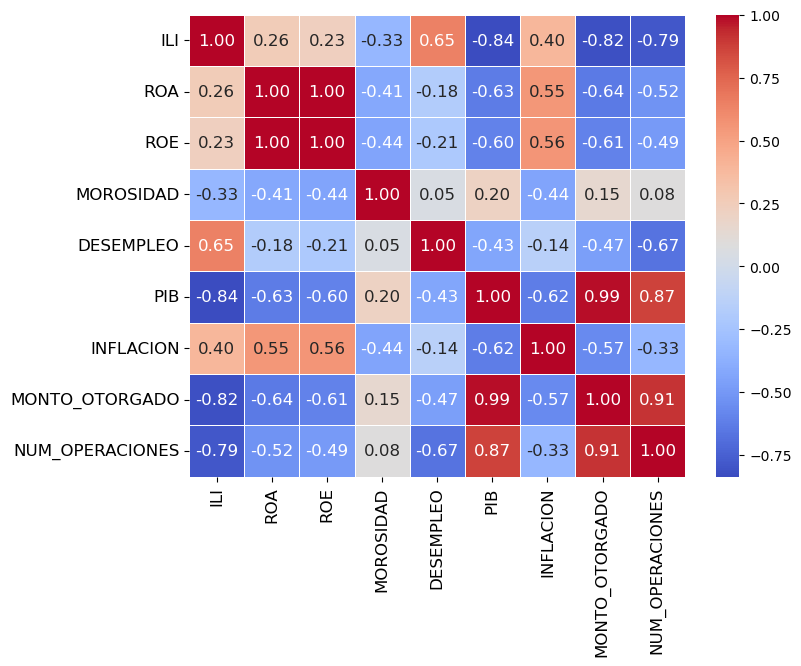

In [49]:
# Matriz de correlación para variables numéricas
# Quitar la columna ANIO

df_sin_anio = df_Indicadores.drop(columns=["ANIO"])

variables_numericas = df_sin_anio.corr(method='kendall')
matriz_corr = variables_numericas.corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    matriz_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    annot_kws={"size": 12}   # Tamaño de los números
)

plt.xticks(fontsize=12)      # Tamaño etiquetas eje X
plt.yticks(fontsize=12)      # Tamaño etiquetas eje Y

plt.show()


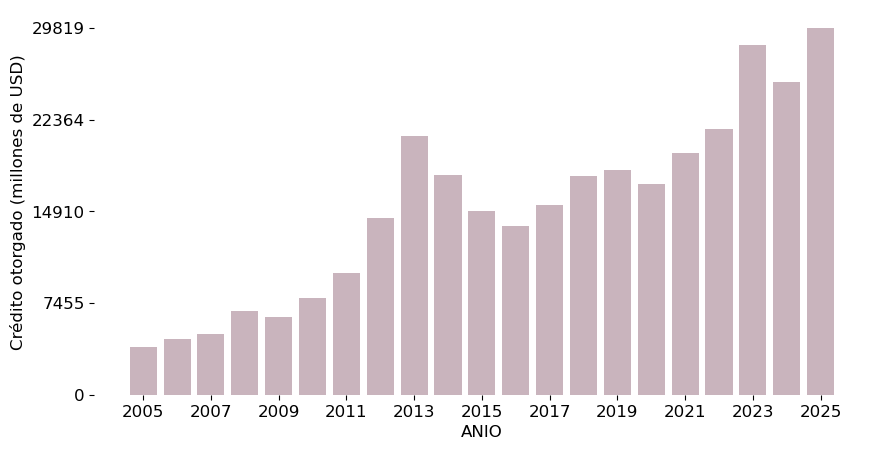

In [50]:
#CREDITO EN MILLONES DE DOLARES POR AÑO
credito_por_anio = (
    df_Indicadores
    .groupby("ANIO")["MONTO_OTORGADO"]
    .sum()
    .reset_index()
    .sort_values("ANIO")
)

credito_por_anio["CREDITO_MILLONES_USD"] = (
    credito_por_anio["MONTO_OTORGADO"] / 1_000_000
)

plt.figure(figsize=(10, 5))

plt.bar(
    credito_por_anio["ANIO"],
    credito_por_anio["CREDITO_MILLONES_USD"],
    color="#c9b4bd",
    edgecolor="none"
)

plt.xlabel("ANIO", fontsize=12)
plt.ylabel("Crédito otorgado (millones de USD)", fontsize=12)
# plt.title("Crédito otorgado anual (millones de dólares)")



# Mostrar solo algunos años en el eje X
anios = sorted(credito_por_anio["ANIO"].unique())
plt.xticks(anios[::2], fontsize=12)


# ---- EJE Y: mostrar pocos valores ----
ax = plt.gca()
y_max = credito_por_anio["CREDITO_MILLONES_USD"].max()
ax.set_yticks(np.linspace(0, y_max, 5))
ax.tick_params(axis='y', labelsize=12)


ax = plt.gca()

for spine in ["top", "right", "left", "bottom"]:
    ax.spines[spine].set_visible(False)



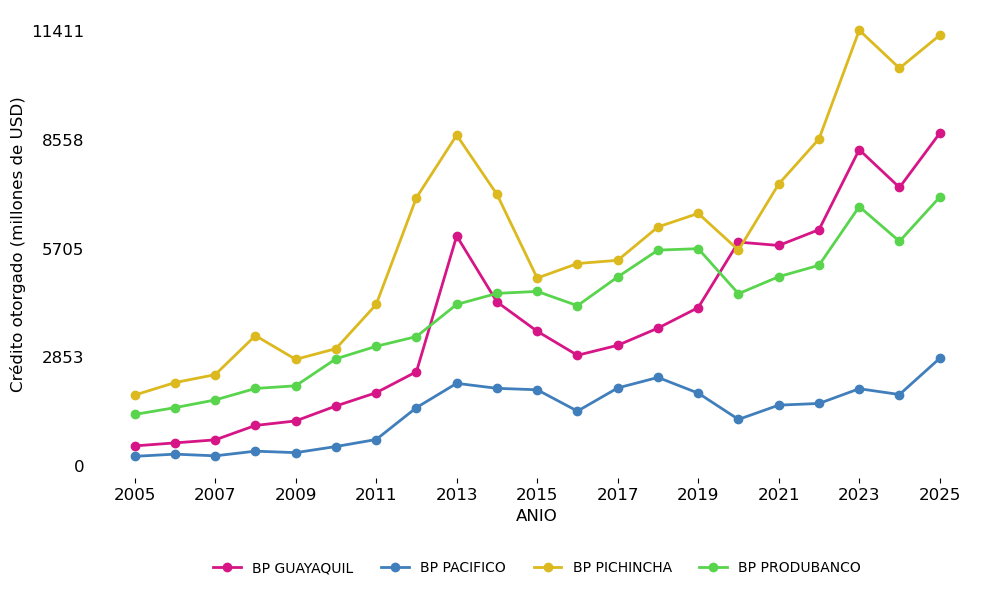

In [51]:
#Créditos por año segun bancos en millones de dólares


credito_anio_banco = (
    df_Bancos
    .groupby(["ANIO", "ENTIDAD"])["MONTO_OTORGADO"]
    .sum()
    .reset_index()
)

credito_anio_banco["CREDITO_MILLONES_USD"] = (
    credito_anio_banco["MONTO_OTORGADO"] / 1_000_000
)

credito_anio_banco = credito_anio_banco.sort_values("ANIO")


colores_pastel = {
    "BP GUAYAQUIL": "#D61586", 
    "BP PACIFICO":  "#407FBB",  
    "BP PICHINCHA": "#DBB91F",  
    "BP PRODUBANCO":"#58D44D"    
}


plt.figure(figsize=(10, 6))

for banco in credito_anio_banco["ENTIDAD"].unique():
    datos_banco = credito_anio_banco[
        credito_anio_banco["ENTIDAD"] == banco
    ]
    
    plt.plot(
        datos_banco["ANIO"],
        datos_banco["CREDITO_MILLONES_USD"],
        linewidth=2,
        marker="o",
        color=colores_pastel[banco],
        label=banco
    )

plt.xlabel("ANIO", fontsize=12)
plt.ylabel("Crédito otorgado (millones de USD)", fontsize=12)
# plt.title("Crédito otorgado anual por banco (millones de dólares)")


# ---- EJE X: mostrar solo algunos años ----
anios = sorted(credito_anio_banco["ANIO"].unique())
plt.xticks(anios[::2], fontsize=12)

# ---- EJE Y: reducir cantidad de etiquetas ----
ax = plt.gca()
y_max = credito_anio_banco["CREDITO_MILLONES_USD"].max()
ax.set_yticks(np.linspace(0, y_max, 5))
ax.tick_params(axis="y", labelsize=12)


# Quitar marco
for spine in ["top", "right", "left", "bottom"]:
    ax.spines[spine].set_visible(False)

# Quitar líneas laterales
ax.tick_params(axis="y", left=False)

# Leyenda inferior en fila
plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=len(colores_pastel),
    frameon=False
)

plt.tight_layout()
plt.show()


#MODELO ARIMA

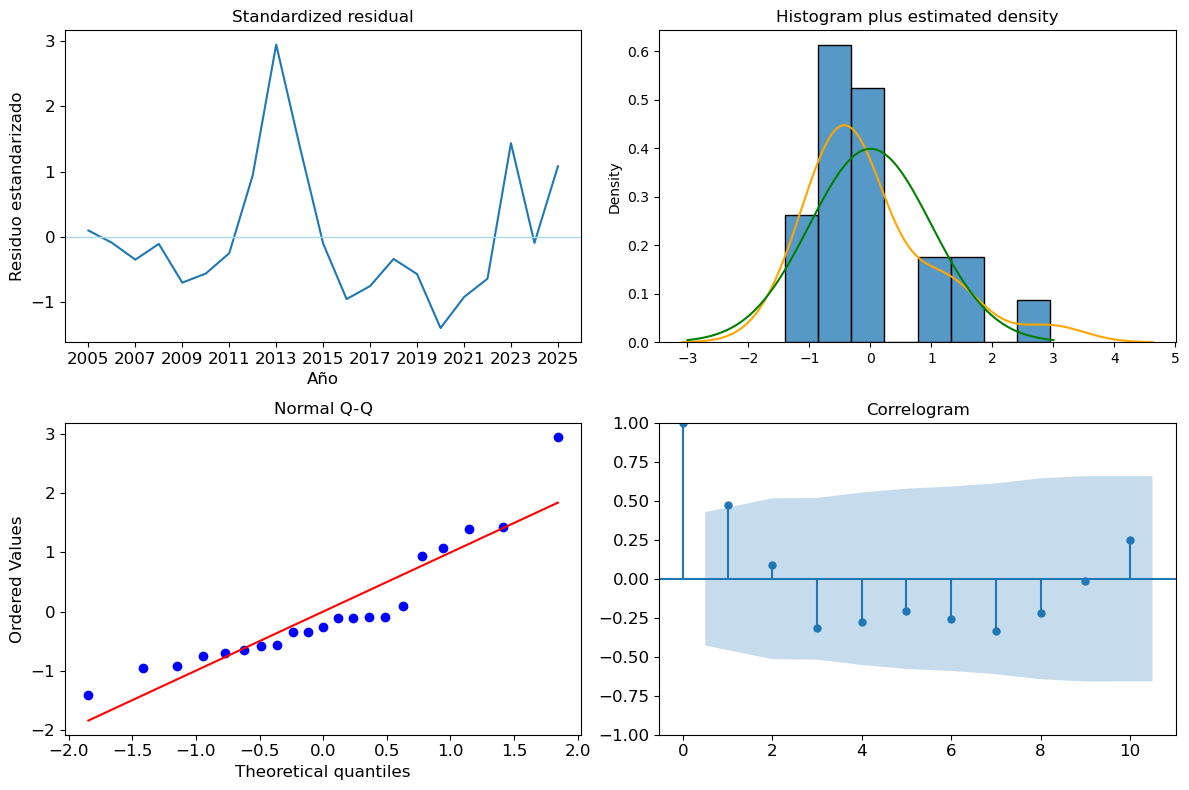

In [52]:
# -----------------------------------
# 1. Serie base: crédito total
# -----------------------------------
y = df_Indicadores["MONTO_OTORGADO"].values
anios = df_Indicadores["ANIO"].values

# -----------------------------------
# 2. Ajuste de tendencia (lineal)
# -----------------------------------
x = np.arange(len(y))
coef = np.polyfit(x, y, 1)
tendencia = coef[0] * x + coef[1]

# -----------------------------------
# 3. Residuos estandarizados
# -----------------------------------
residuos = zscore(y - tendencia)

# -----------------------------------
# 4. Figura 2x2 (diagnóstico)
# -----------------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# (1) Residuos estandarizados en el tiempo
axes[0, 0].plot(anios, residuos, color="tab:blue")
axes[0, 0].axhline(0, color="lightblue", linewidth=1)
axes[0, 0].set_title("Standardized residual", fontsize=12)
axes[0, 0].set_xlabel("Año", fontsize=12)
axes[0, 0].set_ylabel("Residuo estandarizado", fontsize=12)

axes[0, 0].set_xticks(anios[::2])
axes[0, 0].tick_params(axis="x", labelsize=12)
axes[0, 0].tick_params(axis="y", labelsize=12)


# (2) Histograma + KDE + Normal(0,1)
sns.histplot(
    residuos,
    stat="density",
    bins=8,
    color="tab:blue",
    ax=axes[0, 1],
    label="Hist"
)

sns.kdeplot(
    residuos,
    color="orange",
    ax=axes[0, 1],
    label="KDE"
)

x_pdf = np.linspace(-3, 3, 100)
axes[0, 1].plot(
    x_pdf,
    stats.norm.pdf(x_pdf, 0, 1),
    color="green",
    label="N(0,1)"
)

axes[0, 1].set_title("Histogram plus estimated density", fontsize=12)

# Mostrar solo ciertos años
axes[0, 0].set_xticks(anios[::2])
axes[0, 0].tick_params(axis="x", labelsize=12)
axes[0, 0].tick_params(axis="y", labelsize=12)


# (3) Normal Q-Q
stats.probplot(residuos, dist="norm", plot=axes[1, 0])

axes[1, 0].set_title(
    "Normal Q-Q",
    fontsize=12
)
axes[1, 0].set_xlabel("Theoretical quantiles", fontsize=12)
axes[1, 0].set_ylabel("Ordered Values", fontsize=12)
axes[1, 0].tick_params(axis="both", labelsize=12)


# (4) Correlograma (ACF)
plot_acf(residuos, lags=10, ax=axes[1, 1], alpha=0.05)

axes[1, 1].set_title(
    "Correlogram",
    fontsize=12
)
axes[1, 1].tick_params(axis="both", labelsize=12)


plt.tight_layout()
plt.show()


In [53]:
#Prueba de dickier fuller aumentada (ADF) - para verificar estacionariedad

serie = df_Indicadores["MONTO_OTORGADO"]

# Prueba Dickey-Fuller Aumentada
adf_resultado = adfuller(serie, autolag="AIC")

print("Resultados prueba Dickey-Fuller (niveles)")
print("p-value:", adf_resultado[1])



Resultados prueba Dickey-Fuller (niveles)
p-value: 0.928535695331817


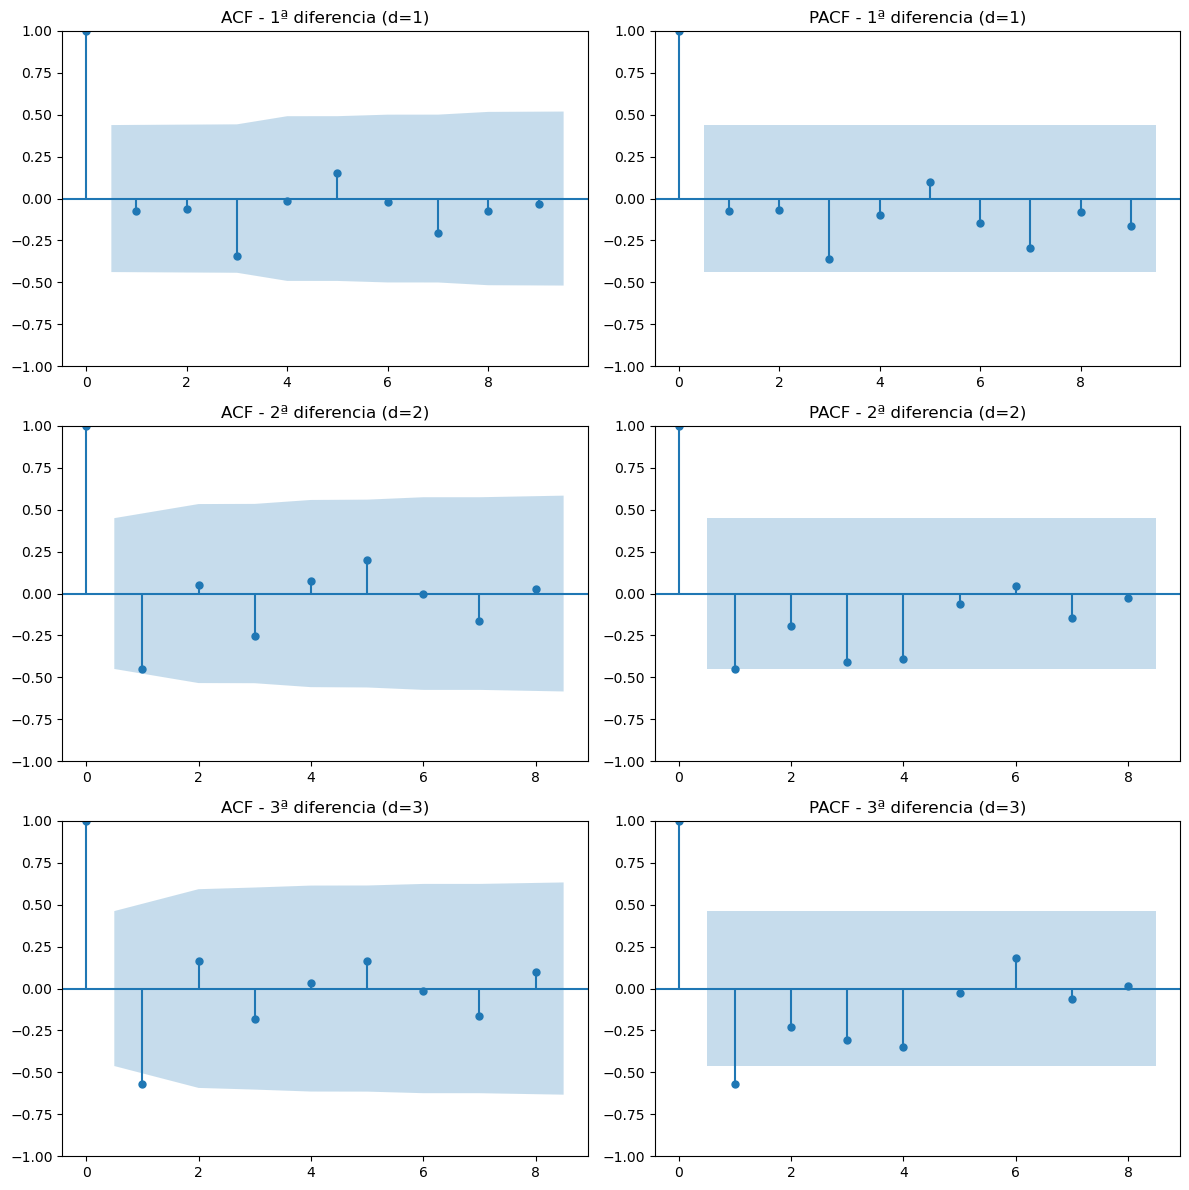

In [54]:
# autocorrelación (ACF) y autocorrelación parcial (PACF)

# Asegurar formato temporal
df = df_Indicadores.copy()
df['ANIO'] = pd.to_datetime(df['ANIO'], format='%Y')
df.set_index('ANIO', inplace=True)

y = df['MONTO_OTORGADO']

#ACF y PACF de la serie (fase de identificación)

y_diff1 = y.diff().dropna()
y_diff2 = y.diff().diff().dropna()
y_diff3 = y.diff().diff().diff().dropna()



series = {
    '1ª diferencia (d=1)': y_diff1,
    '2ª diferencia (d=2)': y_diff2,
    '3ª diferencia (d=3)': y_diff3
}

n_series = len(series)
fig, axs = plt.subplots(
    n_series, 2,
    figsize=(12, 4 * n_series)
)
    

for i, (nombre, serie) in enumerate(series.items()):
    max_lags = min(10, len(serie)//2 - 1)

    plot_acf(serie, ax=axs[i, 0], lags=max_lags)
    axs[i, 0].set_title(f'ACF - {nombre}')

    plot_pacf(serie, ax=axs[i, 1], lags=max_lags)
    axs[i, 1].set_title(f'PACF - {nombre}')

plt.tight_layout()
plt.show()


In [55]:
#DEFINICION DE VARIABLES
X1 = df_Indicadores[
    [
        'NUM_OPERACIONES',
        'ILI',
        'ROA',
        'ROE',
        'MOROSIDAD',
        #'DESEMPLEO',
        #'PIB',
        'INFLACION'
    ]
]

y1 = df_Indicadores['MONTO_OTORGADO']

In [56]:
#VALIDAR MEJOR AIC PARA LOS MODELOS ARIMAX

orders = [(0,1,1), (1,1,0), (1,1,1), (2,1,1)]

for order in orders:
    modelo = SARIMAX(
        y1,
        exog=X1,
        order=order,
        trend='t',
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    try:
        res = modelo.fit(disp=False)
        print(f'Order {order} → AIC: {res.aic:.2f}')
    except:
        print(f'Order {order} → no converge')

Order (0, 1, 1) → AIC: 837.00
Order (1, 1, 0) → AIC: 876.25
Order (1, 1, 1) → AIC: 833.88
Order (2, 1, 1) → AIC: 830.49


In [57]:
#DEFINICION DE VARIABLES
X = df_Indicadores[
    [
        'NUM_OPERACIONES',
        'ILI',
        'ROA',
        'ROE',
        'MOROSIDAD',
        #'DESEMPLEO',
        #'PIB',
        'INFLACION'
    ]
]

y = df_Indicadores['MONTO_OTORGADO']

In [58]:
#MODELO ARIMAX CON ORDEN SELECCIONADO

orders = (1,1,1)  # ARIMA(p,d,q)

for order in orders:
    modelo = SARIMAX(
        y,
        exog=X,
        order=orders,       # ARIMAX(p,d,q)
        trend='t',
        enforce_stationarity=False,
        enforce_invertibility=False
)

resultado = modelo.fit(disp=False)
print(resultado.summary())

                               SARIMAX Results                                
Dep. Variable:         MONTO_OTORGADO   No. Observations:                   21
Model:               SARIMAX(1, 1, 1)   Log Likelihood                -406.941
Date:                Sun, 10 May 2026   AIC                            833.883
Time:                        13:24:05   BIC                            842.786
Sample:                             0   HQIC                           835.110
                                 - 21                                         
Covariance Type:                  opg                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
drift            1.519e+08      0.020   7.73e+09      0.000    1.52e+08    1.52e+08
NUM_OPERACIONES  1.373e+04   2279.411      6.023      0.000    9261.658    1.82e+04
ILI             -4.665e+07      

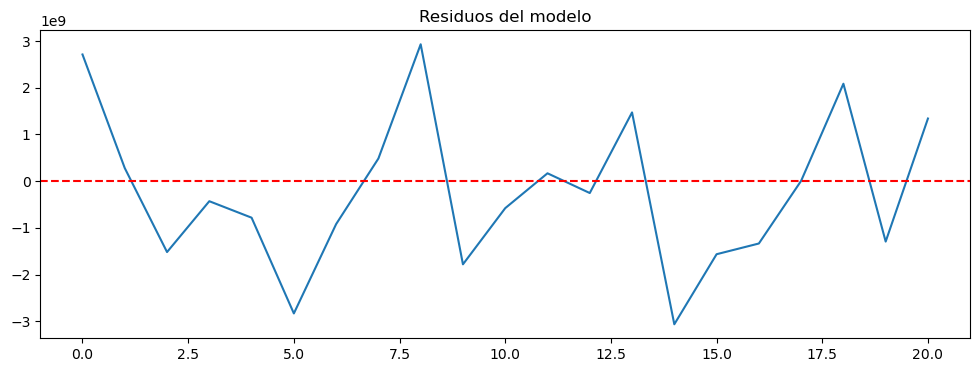

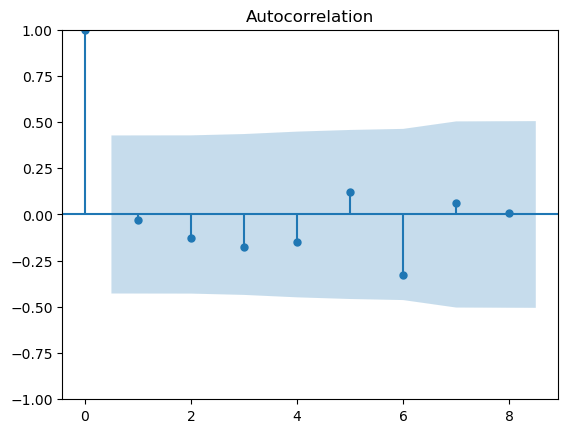

In [59]:
#ERRORES DEL MODELO

residuos = resultado.resid

plt.figure(figsize=(12,4))
plt.plot(residuos)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuos del modelo")
plt.show()



plot_acf(residuos, lags=8)
plt.show()

In [64]:
y_clean = df_Bancos["MONTO_OTORGADO"]
X_clean = df_Bancos[
    ["ILI", "ROA", "ROE", "MOROSIDAD", "DESEMPLEO", "PIB", "INFLACION"]
]

# Eliminar valores faltantes
y_clean = y_clean.dropna()
X_clean = X_clean.loc[y_clean.index]

train = y_clean.iloc[:-3]
test  = y_clean.iloc[-3:]

X_train = X_clean.iloc[:-3]
X_test  = X_clean.iloc[-3:]


model_bt = SARIMAX(
    train,
    exog=X_train,
    order=(1,1,1)
)
res_bt = model_bt.fit(disp=False)

pred_bt = res_bt.get_forecast(steps=3, exog=X_test)


from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(test, pred_bt.predicted_mean)
rmse = np.sqrt(mean_squared_error(test, pred_bt.predicted_mean))

print("MAE:", mae)
print("RMSE:", rmse)


MAE: 643903496.3572197
RMSE: 742972787.4456415


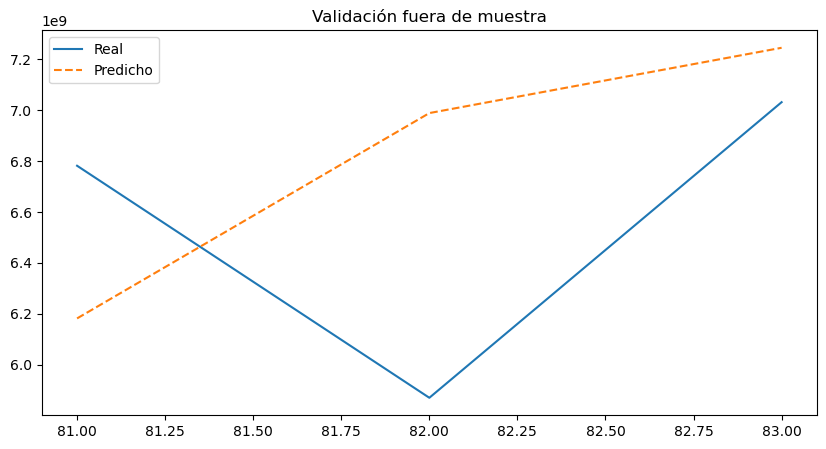

In [65]:
plt.figure(figsize=(10,5))
plt.plot(test.index, test, label='Real')
plt.plot(test.index, pred_bt.predicted_mean, label='Predicho', linestyle='--')
plt.legend()
plt.title("Validación fuera de muestra")
plt.show()

In [72]:
df_Indicadores['ANIO'] = pd.to_numeric(
    df_Indicadores['ANIO'], errors='coerce'
)

resumen_anual = (
    df_Indicadores
    .loc[df_Indicadores['ANIO'].between(2005, 2025)]
    .groupby('ANIO')['MONTO_OTORGADO']
    .sum()
    .round()
    .astype(int)
)

print(resumen_anual)


ANIO
2005     3877128561
2006     4520880527
2007     4966687998
2008     6795290302
2009     6320007314
2010     7863215403
2011     9885092185
2012    14335120329
2013    21023028589
2014    17893978844
2015    14938715240
2016    13755134204
2017    15465751581
2018    17771496394
2019    18293224647
2020    17176524647
2021    19646024861
2022    21585147233
2023    28469870248
2024    25417157250
2025    29819267493
Name: MONTO_OTORGADO, dtype: int64


In [73]:
# Horizonte de predicción
n_years = 5

# Índice temporal futuro (2026–2030)
future_index = pd.date_range(
    start=df.index.max() + pd.DateOffset(years=1),
    periods=n_years,
    freq="YE"
)

# Exógenas futuras (escenario base: valores medios)
X_future = pd.DataFrame(
    data=np.tile(X.mean().values, (n_years, 1)),
    columns=X.columns,
    index=future_index
)

# Pronóstico
forecast1 = resultado.get_forecast(
    steps=n_years,
    exog=X_future
)

forecast_mean = forecast1.predicted_mean
forecast_ci   = forecast1.conf_int()

# ✅ NO AJUSTE MANUAL DEL NIVEL
forecast_mean_adj = forecast_mean
forecast_ci_adj   = forecast_ci


In [74]:

# Unir forecast e intervalos
forecast_final = pd.concat(
    [forecast_mean_adj, forecast_ci_adj],
    axis=1
)

# Renombrar columnas
forecast_final.columns = ["Pronóstico", "IC_Inf", "IC_Sup"]

# ✅ Forzar índice correcto: años 2026–2030
forecast_final.index = pd.date_range(
    start=2026,
    periods=len(forecast_final),
    freq="Y"
)

# ✅ Convertir índice a AÑO en TEXTO
forecast_final.index = [str(y) for y in range(2026, 2026 + len(forecast_final))]
forecast_final.index.name = "Año"

# ✅ Convertir valores a ENTEROS (quitar notación científica)
forecast_final = forecast_final.round(0).astype(int)

forecast_final

C:\Users\Dell\AppData\Local\Temp\ipykernel_4392\479003208.py:11: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  forecast_final.index = pd.date_range(


,Pronóstico,IC_Inf,IC_Sup
Año,,,
2026,27653860115,24490117544,30817602686
2027,30479795062,26837074028,34122516097
2028,32066025191,27518609237,36613441146
2029,34640667754,29630251588,39651083921
2030,36700217648,31091350797,42309084499


In [75]:
# Último valor observado (2025)
last_value_2025 = df.loc[df.index.max(), 'MONTO_OTORGADO']

# Primer valor del forecast original
first_forecast = forecast_mean.iloc[0]
factor = last_value_2025 / first_forecast

# Ajuste para anclar el forecast al 2025
adjustment = last_value_2025 - first_forecast

forecast_mean_adj = forecast_mean * factor

# Ajustar también intervalos de confianza
forecast_ci_adj = forecast_ci * factor


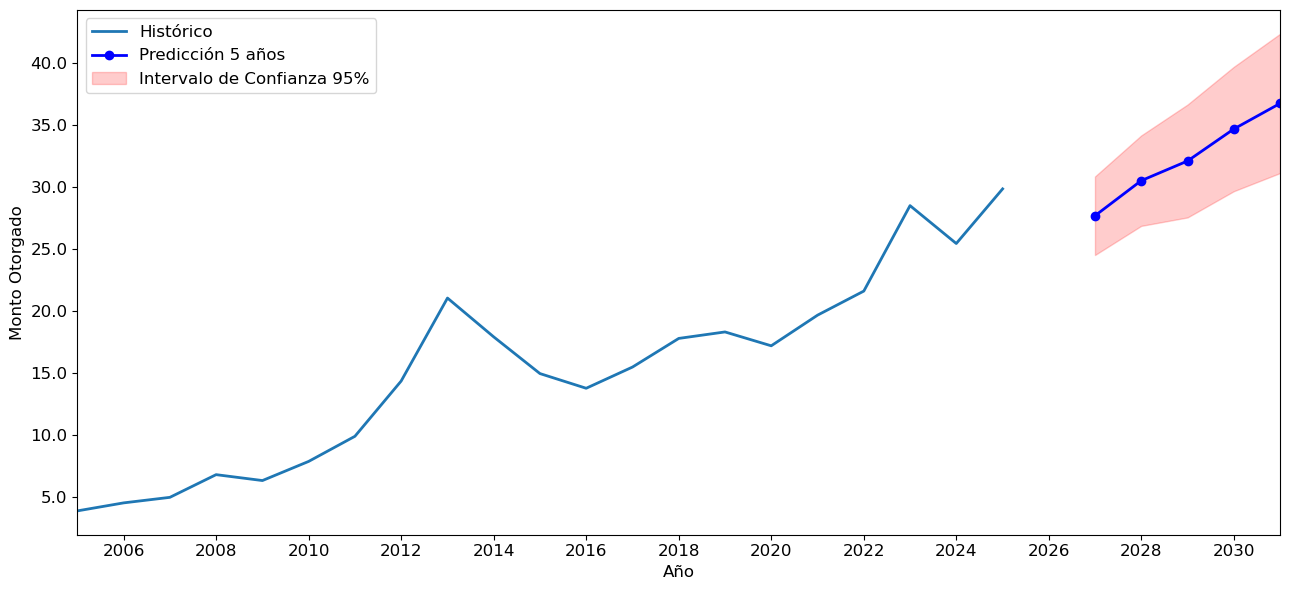

In [76]:
plt.figure(figsize=(13, 6))
ax = plt.gca()

# ======================
# Índices datetime
# ======================
hist_index = pd.to_datetime(df.index)
forecast_index = pd.to_datetime(forecast_final.index + "-12-31")

# ======================
# Gráfico
# ======================
ax.plot(
    hist_index,
    df['MONTO_OTORGADO'].values,
    label='Histórico',
    linewidth=2
)

ax.plot(
    forecast_index,
    forecast_final['Pronóstico'].values,
    label='Predicción 5 años',
    color='blue',
    marker='o',
    linewidth=2
)

ax.fill_between(
    forecast_index,
    forecast_final['IC_Inf'].values,
    forecast_final['IC_Sup'].values,
    color='red',
    alpha=0.2,
    label='Intervalo de Confianza 95%'
)

# ======================
# Formato de ejes
# ======================

# ✅ Eje X: años
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# ✅ Eje Y: miles de millones (quita 1e10)
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x/1e9:.1f}')
)

# ✅ Etiquetas
ax.set_xlabel('Año', fontsize=12)

ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

ax.set_xlabel('Año', fontsize=12)
ax.set_ylabel('Monto Otorgado', fontsize=12)

ax.tick_params(axis='both', labelsize=12)


# ✅ Leyenda legible
ax.legend(fontsize=12)

ax.set_xlim(hist_index.min(), forecast_index.max())

plt.tight_layout()
plt.show()



In [77]:
df = df_Bancos.copy()

df['ANIO'] = pd.to_datetime(df['ANIO'], format='%Y')
df = df.sort_values(['ENTIDAD', 'ANIO'])

exog_vars = [
    'NUM_OPERACIONES',
    'ILI',
    'ROA',
    'ROE',
    'MOROSIDAD',
    'DESEMPLEO',
    'PIB',
    'INFLACION'
]

In [78]:
resultados = {}

for banco in df['ENTIDAD'].unique():

    df_banco = df[df['ENTIDAD'] == banco].set_index('ANIO')

    y = df_banco['MONTO_OTORGADO']
    X = df_banco[exog_vars]

    data = pd.concat([y, X], axis=1).dropna()

    if len(data) < 10:
        continue

    y_clean = data['MONTO_OTORGADO']
    X_clean = data[exog_vars]

    modelo = SARIMAX(
        y_clean,
        exog=X_clean,
        order=(1, 1, 1),
        trend='t',
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    res = modelo.fit(disp=False)

    # Escenario base: último valor de X
    X_last = X_clean.iloc[-1:]
    X_future = pd.concat([X_last]*5)
    X_future.index = pd.date_range(
        start=y_clean.index[-1] + pd.DateOffset(years=1),
        periods=5,
        freq='Y'
    )

    forecast = res.get_forecast(steps=5, exog=X_future)

    resultados[banco] = {
        'historico': y_clean,
        'forecast': forecast.predicted_mean,
        'ci': forecast.conf_int()
    }

c:\Users\Dell\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
c:\Users\Dell\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
C:\Users\Dell\AppData\Local\Temp\ipykernel_4392\1203101833.py:32: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  X_future.index = pd.date_range(
c:\Users\Dell\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
c:\Users\Dell\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be use

In [79]:

# ===============================
# 1. ESTIMACIÓN Y PRONÓSTICO POR BANCO
# ===============================

resultados = {}

for banco in df['ENTIDAD'].unique():

    df_banco = df[df['ENTIDAD'] == banco].set_index('ANIO')

    y = df_banco['MONTO_OTORGADO']
    X = df_banco[exog_vars]

    data = pd.concat([y, X], axis=1).dropna()

    if len(data) < 10:
        continue

    y_clean = data['MONTO_OTORGADO']
    X_clean = data[exog_vars]

    modelo = SARIMAX(
        y_clean,
        exog=X_clean,
        order=(1, 1, 1),
        trend='t',
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    res = modelo.fit(disp=False)

    # Escenario base: último vector de exógenas
    X_last = X_clean.iloc[-1:]
    X_future = pd.concat([X_last] * 5)

    X_future.index = pd.date_range(
        start=y_clean.index.max() + pd.DateOffset(years=1),
        periods=5,
        freq='Y'
    )

    forecast = res.get_forecast(steps=5, exog=X_future)

    resultados[banco] = {
        'forecast': forecast.predicted_mean
    }

# ===============================
# 2. TABLA ÚNICA (FORMATO LARGO)
# ===============================

tablas = []

for banco, res in resultados.items():

    t = res['forecast'].to_frame(name='Pronóstico')

    # Filtrar 2026–2030
    t = t.loc["2026-01-01":"2030-12-31"]

    # ✅ Convertir a MILLONES
    t['Pronóstico'] = (t['Pronóstico'] / 1_000_000).round(2).astype(float)

    # Año en texto
    t['Año'] = t.index.year.astype(str)
    t['Banco'] = banco

    t = t[['Banco', 'Año', 'Pronóstico']]
    tablas.append(t)

tabla_prediccion_bancos = pd.concat(tablas, ignore_index=True)

# ===============================
# 3. TABLA TRANSPUESTA (FINAL)
# ===============================

tabla_transpuesta = tabla_prediccion_bancos.pivot(
    index="Año",
    columns="Banco",
    values="Pronóstico"
)

tabla_transpuesta

c:\Users\Dell\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
c:\Users\Dell\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
C:\Users\Dell\AppData\Local\Temp\ipykernel_4392\767592892.py:37: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  X_future.index = pd.date_range(
c:\Users\Dell\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
c:\Users\Dell\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used

Banco,BP GUAYAQUIL,BP PACIFICO,BP PICHINCHA,BP PRODUBANCO
Año,,,,
2026,8608.96,2498.53,11661.59,6348.69
2027,8824.33,2408.66,12046.47,7397.46
2028,8898.23,2367.42,12452.59,6719.08
2029,9046.77,2336.83,12874.95,7796.44
2030,9167.62,2307.90,13315.13,7122.11


In [80]:
resultados = {}

for banco in df['ENTIDAD'].unique():

    df_banco = df[df['ENTIDAD'] == banco].set_index('ANIO')

    y = df_banco['MONTO_OTORGADO']
    X = df_banco[exog_vars]

    data = pd.concat([y, X], axis=1).dropna()

    if len(data) < 10:
        continue

    y_clean = data['MONTO_OTORGADO']
    X_clean = data[exog_vars]

    modelo = SARIMAX(
        y_clean,
        exog=X_clean,
        order=(1, 1, 1),
        trend='t',
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    res = modelo.fit(disp=False)

    X_last = X_clean.iloc[-1:]
    X_future = pd.concat([X_last] * 5)

    X_future.index = pd.date_range(
        start=y_clean.index.max() + pd.DateOffset(years=1),
        periods=5,
        freq='Y'
    )

    forecast = res.get_forecast(steps=5, exog=X_future)

    # ✅ DEFINICIÓN CORRECTA
    resultados[banco] = {
        'historico': y_clean,
        'forecast': forecast.predicted_mean,
        'ci': forecast.conf_int()
    }


c:\Users\Dell\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
c:\Users\Dell\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
C:\Users\Dell\AppData\Local\Temp\ipykernel_4392\3587008326.py:32: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  X_future.index = pd.date_range(
c:\Users\Dell\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
c:\Users\Dell\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be use

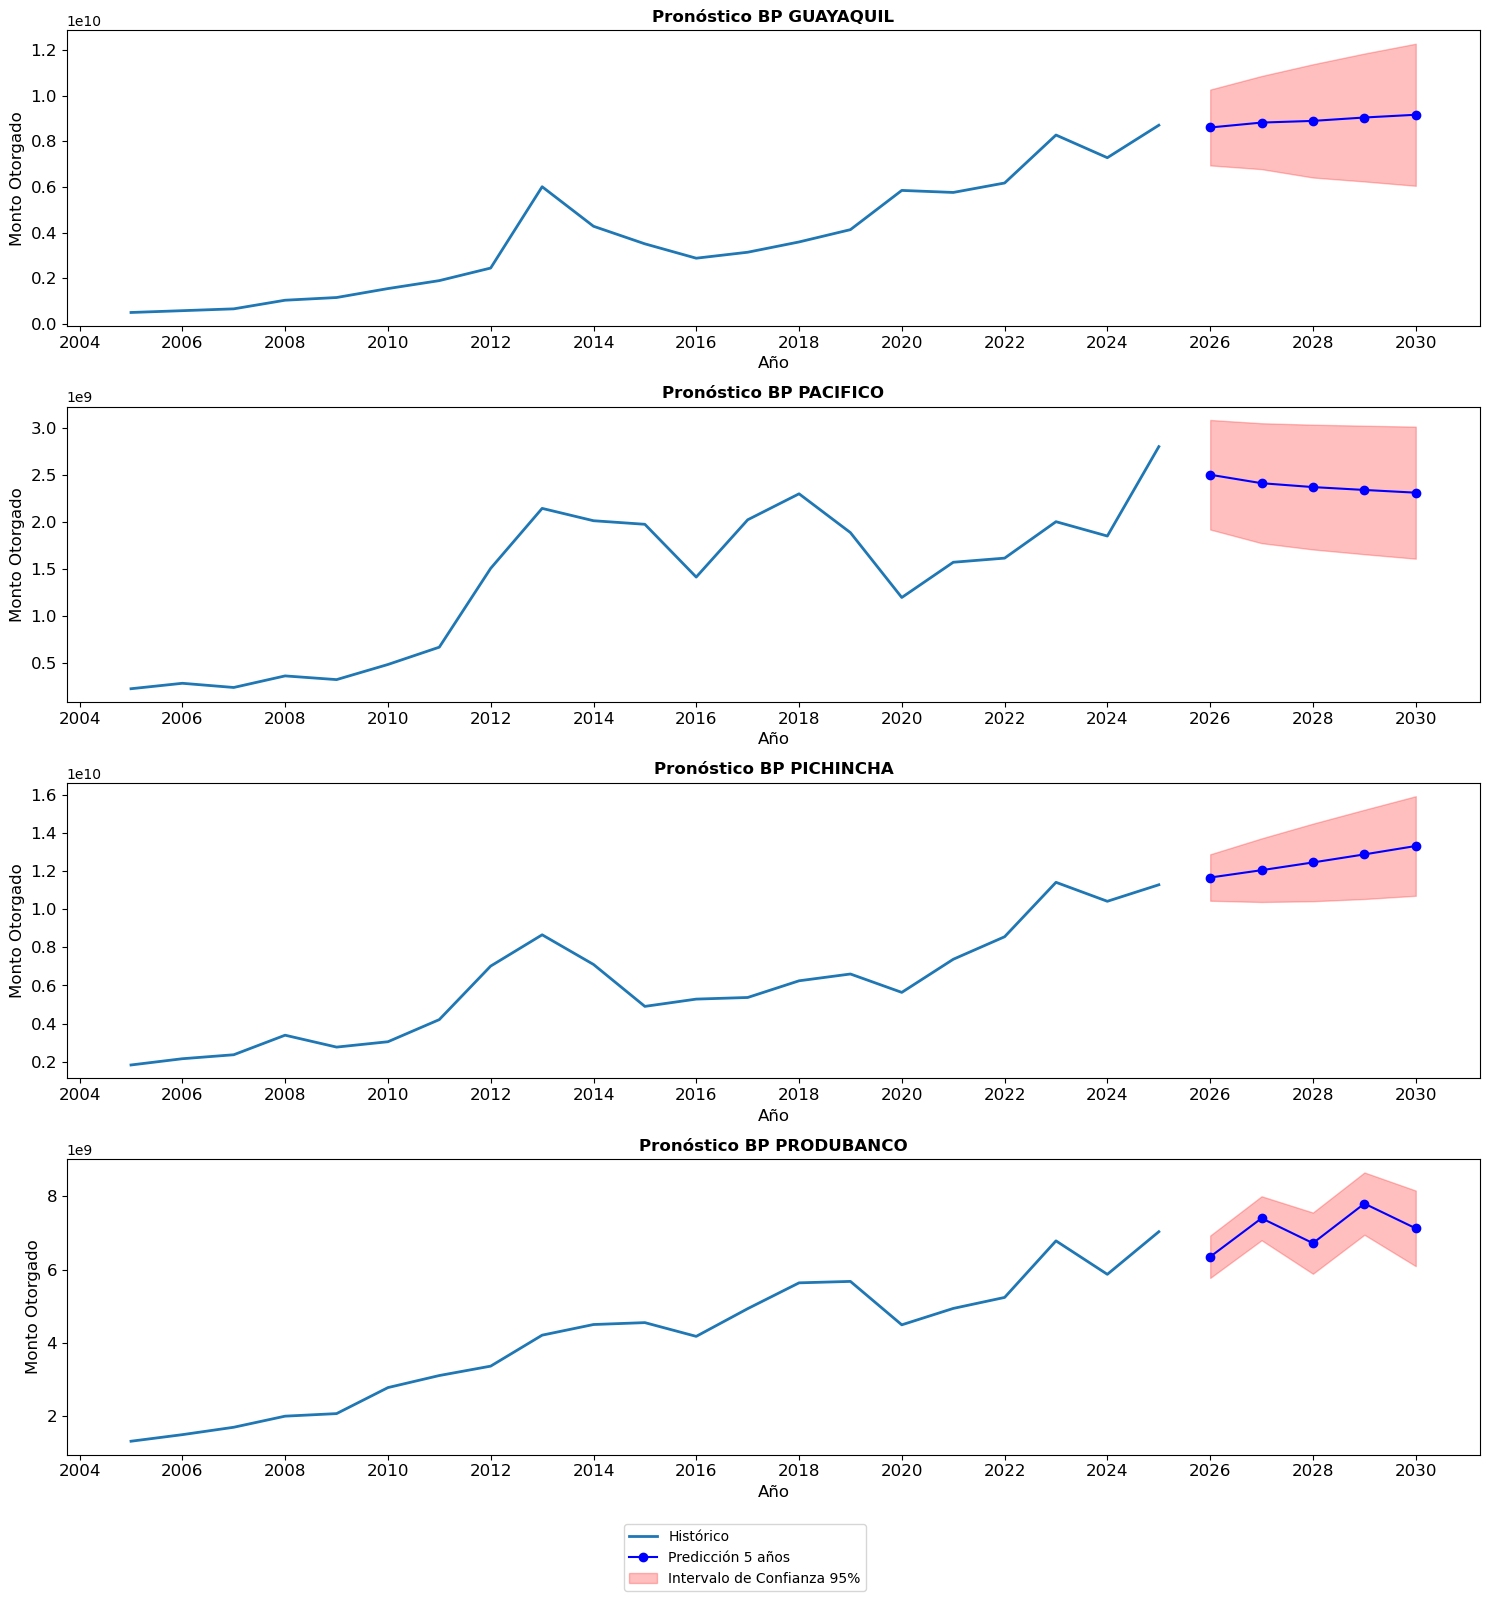

In [81]:

n_bancos = len(resultados)
n_cols = 1
n_rows = n_bancos   # ✅ una fila por banco

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(15, 4 * n_rows),  # ✅ altura proporcional (ideal para tesis)
    sharex=False,
    sharey=False
)

# Si solo hay 1 eje, convertirlo en lista
if n_bancos == 1:
    axes = [axes]
else:
    axes = axes.flatten()



for ax, (banco, res) in zip(axes, resultados.items()):

    ax.tick_params(axis='both', labelsize=12) 

    # Histórico
    ax.plot(
        res['historico'].index,
        res['historico'].values,
        color='tab:blue',
        linewidth=2,
        label='Histórico'
    )

    # Predicción
    ax.plot(
        res['forecast'].index,
        res['forecast'].values,
        color='blue',
        marker='o',
        linewidth=1.5,
        label='Predicción 5 años'
    )

    # Intervalo de confianza
    ax.fill_between(
        res['ci'].index,
        res['ci'].iloc[:, 0],
        res['ci'].iloc[:, 1],
        color='red',
        alpha=0.25,
        label='Intervalo de Confianza 95%'
    )

    # ✅ Mostrar años (puedes cambiar a YearLocator(2) si quieres cada 2 años)
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
   

    ax.set_title(f'Pronóstico {banco}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Año', fontsize=12)
    ax.set_ylabel('Monto Otorgado', fontsize=12)

# ✅ Leyenda general (una sola)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc='lower center',
    ncol=1,
    frameon=True
)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()
